In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Task 1: Gridworld Environment
# -----------------------------

GRID_SIZE = 5
START = (0, 0)
GOAL = (4, 4)

# Obstacles
OBSTACLES = {(1, 1), (2, 2), (3, 1), (3, 3), (1, 3)}

# Actions
ACTIONS = ["UP", "DOWN", "LEFT", "RIGHT"]
ACTION_MAP = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1)
}

# Rewards
R_GOAL = 100
R_STEP = -1
R_OBSTACLE = -10


# Step function
def step(state, action):
    x, y = state
    dx, dy = ACTION_MAP[action]
    nx, ny = x + dx, y + dy

    # Out-of-bound → stay in same state
    if not (0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE):
        return state, R_STEP, False

    # Into obstacle → punish, stay in same state
    if (nx, ny) in OBSTACLES:
        return state, R_OBSTACLE, False

    # Reached goal
    if (nx, ny) == GOAL:
        return (nx, ny), R_GOAL, True

    # Normal step
    return (nx, ny), R_STEP, False


In [3]:
# -----------------------------
# Task 2: Q-Learning
# -----------------------------

alpha = 0.1
gamma = 0.99
epsilon = 0.1
episodes = 1000

# Initialize Q-table
Q = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTIONS)))


# ε-greedy selection
def epsilon_greedy(state):
    if np.random.rand() < epsilon:
        return np.random.choice(len(ACTIONS))
    return np.argmax(Q[state[0], state[1]])


episode_rewards = []

# Training Loop
for ep in range(episodes):
    state = START
    total_reward = 0
    done = False

    while not done:
        a = epsilon_greedy(state)
        action = ACTIONS[a]

        next_state, reward, done = step(state, action)
        total_reward += reward

        # Q-learning update rule
        Q[state[0], state[1], a] += alpha * (
            reward + gamma * np.max(Q[next_state[0], next_state[1]]) -
            Q[state[0], state[1], a]
        )

        state = next_state

    episode_rewards.append(total_reward)


In [4]:
# -----------------------------
# Task 3: Extract Optimal Policy
# -----------------------------

policy = np.full((GRID_SIZE, GRID_SIZE), "", dtype=object)

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        if (i, j) == START:
            policy[i, j] = "S"
        elif (i, j) == GOAL:
            policy[i, j] = "G"
        elif (i, j) in OBSTACLES:
            policy[i, j] = "X"
        else:
            policy[i, j] = ACTIONS[np.argmax(Q[i, j])]

print("\nOptimal Learned Policy:\n")
for row in policy:
    print(row)



Optimal Learned Policy:

['S' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
['DOWN' 'X' 'UP' 'X' 'DOWN']
['DOWN' 'LEFT' 'X' 'RIGHT' 'DOWN']
['DOWN' 'X' 'DOWN' 'X' 'DOWN']
['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'G']


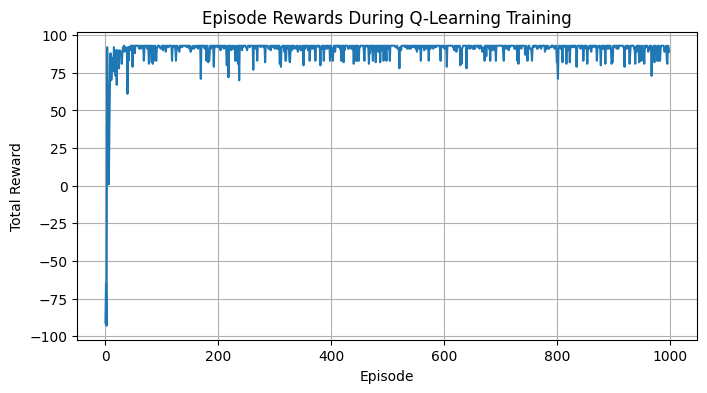

In [5]:
# -----------------------------
# Task 4: Plot Episode Rewards
# -----------------------------

plt.figure(figsize=(8, 4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Episode Rewards During Q-Learning Training")
plt.grid(True)
plt.show()
